# 17 · Publication map of the Bogotá study region — Gate 18

**Purpose.** Build the geographical study-area figure used in the Data section of the manuscript.

The map uses the official EODH 2023 UTAM zoning and the exact territorial classification frozen in Gate 16:

- Bogotá D.C.;
- municipalities required to reach at least 50% of Bogotá–external interface flow;
- additional municipalities required to reach at least 80%;
- remaining municipalities in the complete survey region.

This notebook does not re-estimate accessibility models. It produces a descriptive geographical figure and audits its agreement with the validated analytical node set.


In [7]:
%pip -q install geopandas pyarrow matplotlib adjustText


In [8]:
from pathlib import Path
from datetime import datetime, timezone
import csv, json, os, re, shutil, unicodedata, zipfile

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from adjustText import adjust_text
import numpy as np
import pandas as pd

ROOT = Path("/content/colombia-stochastic-access")
RAW = ROOT / "data/raw/bogota_em2023"
INTERIM = ROOT / "data/interim/bogota_em2023_gate18"
OUT = ROOT / "outputs/bogota_em2023/gate18"
PAPER_FIGURES = ROOT / "paper/figures"
DRIVE_BASE = Path("/content/drive/MyDrive/colombia-stochastic-access-data/bogota_em2023")
for directory in (RAW, INTERIM, OUT, PAPER_FIGURES):
    directory.mkdir(parents=True, exist_ok=True)

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as exc:
    print(f"Environment outside Colab or Drive not mounted: {exc}")

G4 = Path(os.environ.get("GATE4_DIR_OVERRIDE", DRIVE_BASE / "results/gate4"))
G16 = Path(os.environ.get("GATE16_DIR_OVERRIDE", DRIVE_BASE / "results/gate16"))
paths = {
    "region_edges": G4 / "transition_edges_utam.parquet",
    "gate16": G16 / "gate_16.json",
    "interface_rank": G16 / "boundary_interface_municipality_ranking.csv",
    "scope_definitions": G16 / "boundary_scope_definitions.csv",
}
missing = [str(path) for path in paths.values() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing validated inputs: " + ", ".join(missing))

gate16 = json.loads(paths["gate16"].read_text(encoding="utf-8"))
if not gate16.get("gate", {}).get("gate_16_passed", False):
    raise RuntimeError("Gate 16 is not approved")

print("Validated dependency: Gate 16")
print("Output:", OUT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Validated dependency: Gate 16
Output: /content/colombia-stochastic-access/outputs/bogota_em2023/gate18


In [9]:
ZONING_URL = "https://observatorio.movilidadbogota.gov.co/sites/default/files/2025-09/03_Zonificacion%20EODH%20%281%29.zip"

def valid_zip(path):
    path = Path(path)
    return path.exists() and path.stat().st_size > 0 and zipfile.is_zipfile(path)

def ensure_zoning_archive():
    runtime = RAW / "zoning_edoh.zip"
    cached = DRIVE_BASE / "zoning_edoh.zip"
    if valid_zip(runtime):
        return runtime, "runtime_cache"
    if valid_zip(cached):
        shutil.copy2(cached, runtime)
        return runtime, "google_drive_cache"
    from google.colab import files
    print("Select the official EODH zoning ZIP:\n" + ZONING_URL)
    uploaded = files.upload()
    if len(uploaded) != 1:
        raise ValueError("Upload exactly one ZIP")
    name, content = next(iter(uploaded.items()))
    runtime.write_bytes(content)
    if not valid_zip(runtime):
        runtime.unlink(missing_ok=True)
        raise ValueError(f"{name} is not a valid ZIP")
    DRIVE_BASE.mkdir(parents=True, exist_ok=True)
    shutil.copy2(runtime, cached)
    return runtime, "manual_upload"

def safe_extract_recursive(zip_path, destination):
    destination.mkdir(parents=True, exist_ok=True)
    queue = [(Path(zip_path), destination)]
    visited = set()
    while queue:
        current, target = queue.pop(0)
        signature = (str(current.resolve()), str(target.resolve()))
        if signature in visited:
            continue
        visited.add(signature)
        root = target.resolve()
        with zipfile.ZipFile(current) as zipped:
            for member in zipped.infolist():
                resolved = (target / member.filename).resolve()
                if root != resolved and root not in resolved.parents:
                    raise ValueError(f"Unsafe path: {member.filename}")
            zipped.extractall(target)
        for nested in target.rglob("*.zip"):
            nested_target = nested.parent / nested.stem
            if (str(nested.resolve()), str(nested_target.resolve())) not in visited:
                queue.append((nested, nested_target))

archive, retrieval_method = ensure_zoning_archive()
safe_extract_recursive(archive, INTERIM / "zoning_edoh")
print("Zoning:", retrieval_method)


Zoning: runtime_cache


In [10]:
def normalize(value):
    if pd.isna(value):
        return ""
    value = unicodedata.normalize("NFKD", str(value))
    value = "".join(char for char in value if not unicodedata.combining(char))
    return re.sub(r"[^a-z0-9]+", "_", value.lower().strip()).strip("_")

def canonical_utam(series):
    cleaned = series.astype("string").str.strip().str.replace(r"\.0$", "", regex=True)
    def one(value):
        if pd.isna(value):
            return pd.NA
        text = str(value).strip().upper().replace(" ", "")
        match = re.fullmatch(r"UPR0*(\d+)", text)
        if match:
            return f"UPR{int(match.group(1)):04d}"
        match = re.fullmatch(r"(?:UTAM)?0*(\d+)", text)
        return f"UTAM{int(match.group(1)):03d}" if match else text
    return cleaned.map(one).astype("string")

spatial_paths = (
    list((INTERIM / "zoning_edoh").rglob("*.shp"))
    + list((INTERIM / "zoning_edoh").rglob("*.geojson"))
    + list((INTERIM / "zoning_edoh").rglob("*.gpkg"))
)
candidates = []
for path in spatial_paths:
    try:
        columns = {normalize(column): column for column in gpd.read_file(path, rows=5).columns}
        if "utam" in columns:
            candidates.append(path)
    except Exception:
        continue
if not candidates:
    raise FileNotFoundError("UTAM zoning layer not found")

utam_path = sorted(
    candidates,
    key=lambda path: ("utam2023" not in normalize(path.stem), len(path.parts)),
)[0]
layer = gpd.read_file(utam_path)
column_map = {normalize(column): column for column in layer.columns}
municipality_key = (
    "munnombre" if "munnombre" in column_map
    else next(key for key in column_map if "mun" in key and "nombre" in key)
)
layer["utam"] = canonical_utam(layer[column_map["utam"]])
layer["municipality_raw"] = layer[column_map[municipality_key]].astype("string").str.strip()
layer["municipality_normalized"] = layer["municipality_raw"].map(normalize)

edges = pd.read_parquet(paths["region_edges"])
edges["utam_ori"] = canonical_utam(edges["utam_ori"])
edges["utam_des"] = canonical_utam(edges["utam_des"])
region_nodes = set(edges["utam_ori"]) | set(edges["utam_des"])
region = layer[layer["utam"].isin(region_nodes)].copy()
if region.empty:
    raise RuntimeError("No validated regional nodes matched the zoning layer")

interface_rank = pd.read_csv(paths["interface_rank"])
interface_rank["external_municipality"] = interface_rank["external_municipality"].map(normalize)
interface_rank = interface_rank.sort_values("rank").reset_index(drop=True)

def municipalities_to_threshold(threshold):
    crossing = np.flatnonzero(
        interface_rank["cumulative_interface_share"].to_numpy(float) >= threshold
    )
    number = int(crossing[0] + 1) if len(crossing) else len(interface_rank)
    return set(interface_rank.head(number)["external_municipality"])

functional_50 = municipalities_to_threshold(0.50)
functional_80 = municipalities_to_threshold(0.80)
external_region = set(interface_rank["external_municipality"])

def scope_class(municipality):
    key = normalize(municipality)
    if "bogota" in key:
        return "Bogotá D.C."
    if key in functional_50:
        return "Functional 50% threshold"
    if key in functional_80:
        return "Added by 80% threshold"
    if key in external_region:
        return "Remaining survey region"
    return "Municipality label unavailable"

region["scope_class"] = region["municipality_raw"].map(scope_class)
region["municipality_display"] = (
    region["municipality_raw"].fillna("Unassigned UTAM").str.title()
)
region.loc[region["scope_class"].eq("Bogotá D.C."), "municipality_display"] = "Bogotá D.C."
region.loc[
    region["scope_class"].eq("Municipality label unavailable"),
    "municipality_display",
] = "Unassigned UTAM"

region = region.to_crs(epsg=3116)
municipalities = region.dissolve(
    by=["municipality_display", "scope_class"], as_index=False
)
municipalities["label_point"] = municipalities.geometry.representative_point()

classification = municipalities[
    ["municipality_display", "scope_class"]
].sort_values(["scope_class", "municipality_display"])
classification.to_csv(OUT / "study_area_municipality_classification.csv", index=False)

print("UTAM nodes represented:", region["utam"].nunique(), "/", len(region_nodes))
print("Mapped municipalities:", municipalities["municipality_display"].nunique())
display(classification)


UTAM nodes represented: 140 / 141
Mapped municipalities: 21


,municipality_display,scope_class
3,Chia,Added by 80% threshold
5,Cota,Added by 80% threshold
8,Funza,Added by 80% threshold
12,Mosquera,Added by 80% threshold
0,Bogotá D.C.,Bogotá D.C.
14,Soacha,Functional 50% threshold
1,Bojaca,Remaining survey region
2,Cajica,Remaining survey region
4,Choachí,Remaining survey region
6,El Rosal,Remaining survey region


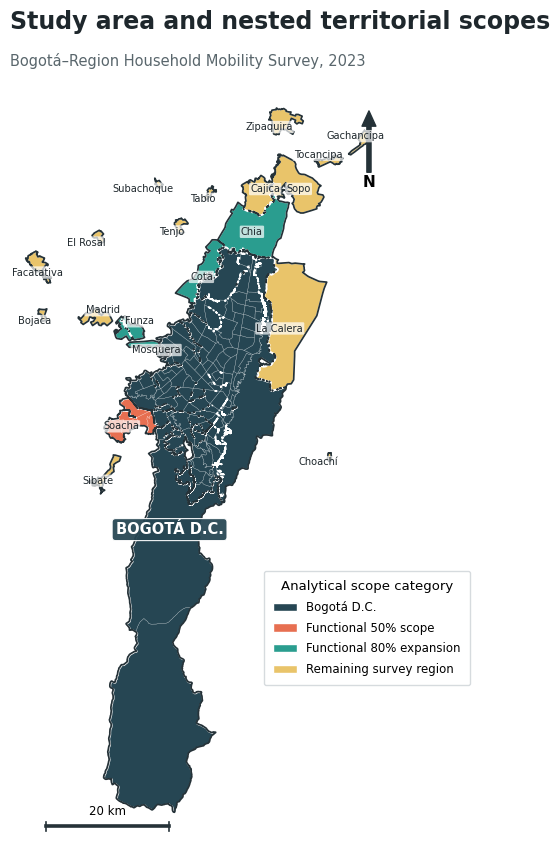

PNG: /content/colombia-stochastic-access/outputs/bogota_em2023/gate18/figure_study_area_multiscale_scopes.png
PDF: /content/colombia-stochastic-access/outputs/bogota_em2023/gate18/figure_study_area_multiscale_scopes.pdf


In [14]:
palette = {
    "Bogotá D.C.": "#264653",
    "Functional 50% threshold": "#E76F51",
    "Added by 80% threshold": "#2A9D8F",
    "Remaining survey region": "#E9C46A",
    "Municipality label unavailable": "#B8B8B8",
}
draw_order = [
    "Remaining survey region",
    "Added by 80% threshold",
    "Functional 50% threshold",
    "Bogotá D.C.",
    "Municipality label unavailable",
]

fig, ax = plt.subplots(figsize=(11.2, 9.2), facecolor="white")
for category in draw_order:
    frame = municipalities[municipalities["scope_class"].eq(category)]
    if not frame.empty:
        frame.plot(
            ax=ax, color=palette[category], edgecolor="white",
            linewidth=1.25, zorder=2,
        )

# Subtle UTAM structure and strong regional outline.
region.boundary.plot(ax=ax, color="white", linewidth=0.22, alpha=0.55, zorder=3)
region.dissolve().boundary.plot(ax=ax, color="#253238", linewidth=1.25, zorder=4)

texts = []
for row in municipalities.itertuples(index=False):
    x, y = row.label_point.x, row.label_point.y
    if row.scope_class == "Bogotá D.C.":
        ax.text(
            x, y, "BOGOTÁ D.C.", ha="center", va="center",
            fontsize=10.5, fontweight="bold", color="white", zorder=7,
            bbox=dict(boxstyle="round,pad=0.24", facecolor="#264653",
                      edgecolor="white", linewidth=0.8, alpha=0.94),
        )
    elif row.scope_class != "Municipality label unavailable":
        texts.append(ax.text(
            x, y, row.municipality_display, ha="center", va="center",
            fontsize=7.1, color="#1E272C", zorder=7,
            bbox=dict(boxstyle="round,pad=0.12", facecolor="white",
                      edgecolor="none", alpha=0.70),
        ))

adjust_text(
    texts, ax=ax, only_move={"text": "xy"},
    expand=(1.04, 1.10), force_text=(0.10, 0.18),
    arrowprops=dict(arrowstyle="-", color="#5F6B70", lw=0.45, alpha=0.75),
)

xmin, ymin, xmax, ymax = region.total_bounds
width, height = xmax - xmin, ymax - ymin
ax.set_xlim(xmin - 0.045 * width, xmax + 0.045 * width)
ax.set_ylim(ymin - 0.055 * height, ymax + 0.075 * height)

# North arrow.
ax.annotate(
    "N", xy=(0.955, 0.93), xytext=(0.955, 0.84),
    xycoords="axes fraction", textcoords="axes fraction",
    ha="center", va="center", fontsize=11, fontweight="bold",
    arrowprops=dict(facecolor="#253238", edgecolor="#253238",
                    width=3.0, headwidth=10, headlength=11),
)

# 20 km scale bar in projected metres.
scale_m = 20_000
sx = xmin + 0.06 * width
sy = ymin - 0.020 * height
ax.plot([sx, sx + scale_m], [sy, sy], color="#253238", lw=2.6, zorder=8)
ax.plot([sx, sx], [sy - 0.006 * height, sy + 0.006 * height], color="#253238", lw=1.2)
ax.plot([sx + scale_m, sx + scale_m], [sy - 0.006 * height, sy + 0.006 * height], color="#253238", lw=1.2)
ax.text(sx + scale_m / 2, sy + 0.012 * height, "20 km", ha="center", va="bottom", fontsize=8.5)

handles = [
    Patch(facecolor=palette["Bogotá D.C."], edgecolor="white", label="Bogotá D.C."),
    Patch(facecolor=palette["Functional 50% threshold"], edgecolor="white",
          label="Functional 50% scope"),
    Patch(facecolor=palette["Added by 80% threshold"], edgecolor="white",
          label="Functional 80% expansion"),
    Patch(facecolor=palette["Remaining survey region"], edgecolor="white",
          label="Remaining survey region"),
]
ax.legend(
    handles=handles, loc="center left", bbox_to_anchor=(0.66, 0.28),
    frameon=True, framealpha=0.96, facecolor="white",
    edgecolor="#D5DADD", fontsize=8.5,
    title="Analytical scope category", title_fontsize=9.5,
    borderpad=0.8, labelspacing=0.65,
)

ax.set_title(
    "Study area and nested territorial scopes",
    loc="left", fontsize=17, fontweight="bold",
    color="#1E272C", pad=8,
)
ax.text(
    0.0, 1.003,
    "Bogotá–Region Household Mobility Survey, 2023",
    transform=ax.transAxes, ha="left", va="top",
    fontsize=10.5, color="#59666C",
)
ax.set_axis_off()
fig.subplots_adjust(left=0.02, right=0.98, top=0.89, bottom=0.025)

png_path = OUT / "figure_study_area_multiscale_scopes.png"
pdf_path = OUT / "figure_study_area_multiscale_scopes.pdf"
fig.savefig(png_path, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
shutil.copy2(png_path, PAPER_FIGURES / png_path.name)
plt.show()

print("PNG:", png_path)
print("PDF:", pdf_path)


In [12]:
mapping_coverage = float(region["utam"].nunique() / len(region_nodes))
scope_classes = set(municipalities["scope_class"])
expected_classes = {
    "Bogotá D.C.",
    "Functional 50% threshold",
    "Added by 80% threshold",
    "Remaining survey region",
}
checks = {
    "gate16_dependency_valid": True,
    "validated_node_mapping_at_least_99_percent": bool(mapping_coverage >= 0.99),
    "all_four_scope_classes_present": bool(expected_classes <= scope_classes),
    "functional_50_is_soacha": bool(functional_50 == {"soacha"}),
    "functional_80_has_five_municipalities": bool(len(functional_80) == 5),
    "all_twenty_external_municipalities_represented": bool(
        external_region <= set(region["municipality_normalized"])
    ),
    "municipal_geometries_valid": bool(
        municipalities.geometry.notna().all()
        and municipalities.geometry.is_valid.all()
        and (~municipalities.geometry.is_empty).all()
    ),
    "publication_png_created": bool(png_path.exists() and png_path.stat().st_size > 0),
    "vector_pdf_created": bool(pdf_path.exists() and pdf_path.stat().st_size > 0),
    "classification_table_complete": bool(len(classification) >= 21),
}
checks["gate_18_passed"] = bool(all(checks.values()))

report = {
    "generated_utc": datetime.now(timezone.utc).isoformat(),
    "purpose": "publication study-area map aligned with Gate 16 territorial scopes",
    "zoning_source": str(utam_path),
    "zoning_retrieval_method": retrieval_method,
    "crs": str(region.crs),
    "validated_nodes": int(len(region_nodes)),
    "mapped_nodes": int(region["utam"].nunique()),
    "mapping_coverage": mapping_coverage,
    "external_municipalities": int(len(external_region)),
    "scope_membership": {
        "functional_50": sorted(functional_50),
        "functional_80": sorted(functional_80),
    },
    "gate": checks,
}
(OUT / "gate_18.json").write_text(
    json.dumps(report, ensure_ascii=False, indent=2, allow_nan=False),
    encoding="utf-8",
)
pd.Series(checks, name="result").to_csv(OUT / "gate_18_checks.csv")

persistent = DRIVE_BASE / "results/gate18"
persistent.mkdir(parents=True, exist_ok=True)
for artifact in OUT.iterdir():
    if artifact.is_file():
        shutil.copy2(artifact, persistent / artifact.name)

display(pd.Series(checks, name="result"))
print("Gate 18:", "PASSED" if checks["gate_18_passed"] else "FAILED")
print("Persistent copy:", persistent)


,result
gate16_dependency_valid,True
validated_node_mapping_at_least_99_percent,True
all_four_scope_classes_present,True
functional_50_is_soacha,True
functional_80_has_five_municipalities,True
all_twenty_external_municipalities_represented,True
municipal_geometries_valid,True
publication_png_created,True
vector_pdf_created,True
classification_table_complete,True


Gate 18: PASSED
Persistent copy: /content/drive/MyDrive/colombia-stochastic-access-data/bogota_em2023/results/gate18
